In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import shap
import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors, rdMolDescriptors

import warnings
warnings.filterwarnings("ignore")

/home/rezazng/miniconda3/envs/photocatalyst-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration
RANDOM_STATE = 42
TARGET_COL = "Removal %"
TIME_COL = "Rxn Time (min)"

In [3]:
df = pd.read_csv("../data/Data.csv")
print(f"Loaded shape: {df.shape}")

df.sample(10, random_state=RANDOM_STATE)

Loaded shape: (162, 3)


,Dye,Rxn Time (min),Removal %
158,CS-3B,10,0.363633
109,BF,5,0.409810
131,Fl,25,0.983809
55,PonS,5,0.298214
94,Reso,20,0.831068
29,R6G,25,0.758447
101,DMMB,25,0.709923
51,Ab,15,0.600005
100,DMMB,20,0.660136
144,MG,0,0.000000


In [4]:
buffer_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
})

buffer_info

,dtype,n_unique,n_missing
Dye,object,27,0
Rxn Time (min),int64,6,0
Removal %,float64,136,0


In [5]:
# Duplicate analysis
n_exact_duplicates = df.duplicated().sum()

print(f"Exact duplicate rows: {n_exact_duplicates}")

if n_exact_duplicates > 0:
    duplicates_df = (
        df[df.duplicated(keep=False)]
        .sort_values(by=df.columns.tolist())
    )

    display(duplicates_df)

Exact duplicate rows: 0


In [6]:
dye_name_map = {
    "MB": "Methylene Blue",
    "MO": "Methyl Orange",
    "Tart": "Tartrazine",
    "RhB": "Rhodamine B",
    "R6G": "Rhodamine 6G",
    "Am": "Amaranth",
    "CV": "Crystal Violet",
    "MaG": "Malachite Green",
    "Ab": "Amido Black 10B",
    "PonS": "Ponceau S",
    "BBR": "Coomassie Brilliant Blue R-250",
    "BBG": "Coomassie Brilliant Blue G-250",
    "CB": "Cibacron Blue 3GA",
    "BPB": "Bromophenol Blue",
    "Erio": "Erioglaucine",
    "Reso": "Resorufin",
    "DR80": "Direct Red 80",
    "Congo": "Congo Red",
    "DMMB": "Dimethylmethylene Blue",
    "BF": "Basic Fuchsin",
    "Fl": "Fluorescein",
    "NBA": "Nile Blue A",
    "OG": "Orange G",
    "CS-3B": "Crocein Scarlet 3B",
    "FBMBSN": "Solvent Blue 38",
    "MG": "Methyl green chloride",
    "BCB": "Brilliant Cresyl Blue ALD",
}

In [7]:
# Validate dye names

if "Dye" not in df.columns:
    raise KeyError(
        f"'Dye' column was not found. Available columns: {df.columns.tolist()}"
    )

unique_dyes = (
    df["Dye"]
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

missing_from_map = [
    dye for dye in unique_dyes
    if dye not in dye_name_map
]

if missing_from_map:
    print("\nWARNING: These dye codes are missing from dye_name_map:")

    for dye in missing_from_map:
        print(f"  - {dye}")

In [8]:
def fetch_smiles_from_pubchem(dye_code):
    """
    Fetch Canonical SMILES from PubChem using the mapped dye name.
    """

    dye_code = str(dye_code).strip()

    compound_name = dye_name_map.get(dye_code)

    if compound_name is None:
        print(
            f"[NAME MAP FAILED] "
            f"No full name defined for '{dye_code}'"
        )
        return None

    try:
        compounds = pcp.get_compounds(
            compound_name,
            namespace="name"
        )

        if not compounds:
            print(
                f"[PUBCHEM FAILED] "
                f"{dye_code} -> {compound_name}"
            )
            return None

        compound = compounds[0]

        smiles = compound.canonical_smiles

        if not smiles:
            print(
                f"[NO SMILES] "
                f"{dye_code} -> {compound_name}"
            )
            return None

        return smiles

    except Exception as exc:
        print(
            f"[PUBCHEM ERROR] "
            f"{dye_code} -> {compound_name}: {exc}"
        )
        return None

In [9]:
def extract_chemical_features_direct(dye_list):
    """
    Fetch molecular structures from PubChem, calculate
    molecular descriptors using RDKit, and return both
    the descriptor dataframe and descriptor column names.
    """

    feature_rows = []

    for dye_code in dye_list:

        dye_code = str(dye_code).strip()

        smiles = fetch_smiles_from_pubchem(dye_code)

        if smiles is None:
            continue

        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            print(
                f"[RDKIT FAILED] "
                f"Could not parse SMILES for '{dye_code}'"
            )
            continue

        descriptor_row = {
        
            # Identification columns
            "Dye": dye_code,
            "Full_Name": dye_name_map[dye_code],
            "SMILES": smiles,

            # Molecular size descriptors

            # "MW": round(Descriptors.MolWt(mol), 3),
            # "Labute_ASA": round(rdMolDescriptors.CalcLabuteASA(mol), 3),
            # "Heavy_Atom_Count": Descriptors.HeavyAtomCount(mol),

            # Polarity / hydrophobicity
            # "TPSA": round(Descriptors.TPSA(mol), 3),
            "LogP": round(Descriptors.MolLogP(mol), 3),

            # Hydrogen-bonding capability
            "HBD": Descriptors.NumHDonors(mol),
            "HBA": Descriptors.NumHAcceptors(mol),

            # Structural / aromatic descriptors
            "Aromatic_Rings": Descriptors.NumAromaticRings(mol),
            # "Ring_Count": Descriptors.RingCount(mol),
            "Rotatable_Bonds": Descriptors.NumRotatableBonds(mol),
            "Fraction_Csp3": round(Descriptors.FractionCSP3(mol), 3),

            # Chemical composition
            # "Heteroatoms": Descriptors.NumHeteroatoms(mol),
        }

        feature_rows.append(descriptor_row)

    dye_features = pd.DataFrame(feature_rows)

    if dye_features.empty:
        return dye_features, []

    # Automatically detect descriptor columns
    metadata_cols = {
        "Dye",
        "Full_Name",
        "SMILES",
    }

    descriptor_cols = [
        col
        for col in dye_features.columns
        if col not in metadata_cols
    ]

    return dye_features, descriptor_cols

In [10]:
# Generate descriptor table

dye_features, descriptor_cols = extract_chemical_features_direct(
    unique_dyes
)

print("\nDescriptor table shape:", dye_features.shape)
display(dye_features.sample(10, random_state=RANDOM_STATE))


Descriptor table shape: (27, 9)


,Dye,Full_Name,SMILES,LogP,HBD,HBA,Aromatic_Rings,Rotatable_Bonds,Fraction_Csp3
8,Ab,Amido Black 10B,C1=CC=C(C=C1)N=NC2=C(C3=C(C(=C(C=C3C=C2S(=O)(=...,-1.317,2,14,4,7,0.000
13,BPB,Bromophenol Blue,C1=CC=C2C(=C1)C(OS2(=O)=O)(C3=CC(=C(C(=C3)Br)O...,6.159,2,5,3,2,0.053
9,PonS,Ponceau S,C1=CC(=CC=C1N=NC2=CC(=C(C=C2)N=NC3=C4C=CC(=CC4...,-8.991,1,17,4,8,0.000
21,Fl,Fluorescein,C1=CC=C2C(=C1)C(=O)OC23C4=C(C=C(C=C4)O)OC5=C3C...,3.666,2,5,3,0,0.050
0,MB,Methylene Blue,CN(C)C1=CC2=C(C=C1)N=C3C=CC(=[N+](C)C)C=C3S2.[...,-0.497,0,3,1,1,0.250
11,BBG,Coomassie Brilliant Blue G-250,CCN(CC1=CC(=CC=C1)S(=O)(=O)[O-])C2=CC(=C(C=C2)...,5.968,1,9,5,15,0.213
16,DMMB,Dimethylmethylene Blue,CC1=CC(=CC2=C1N=C3C(=CC(=[N+](C)C)C=C3S2)C)N(C...,0.120,0,3,1,1,0.333
17,DR80,Direct Red 80,C1=CC(=CC=C1N=NC2=CC(=C(C=C2)N=NC3=C(C=C4C=C(C...,-9.842,4,29,8,16,0.000
12,CB,Cibacron Blue 3GA,C1=CC=C2C(=C1)C(=O)C3=C(C2=O)C(=C(C=C3NC4=CC(=...,3.854,7,15,5,9,0.000
24,MG,Methyl green chloride,CN(C)C1=CC=C(C=C1)C(=C2C=CC(=[N+](C)C)C=C2)C3=...,-1.402,0,1,2,4,0.269


In [11]:
# Check unsuccessful PubChem/RDKit lookups

resolved_dyes = set(dye_features["Dye"])

missing_lookup = [
    dye for dye in unique_dyes
    if dye not in resolved_dyes
]

if missing_lookup:

    print("\nDescriptors were NOT generated for:")

    for dye in missing_lookup:
        print(
            f"  {dye:8s} -> "
            f"{dye_name_map.get(dye, 'UNKNOWN')}"
        )

else:
    print("\nAll dyes successfully resolved")


All dyes successfully resolved


In [12]:
df = df.merge(
    dye_features,
    on="Dye",
    how="left",
    validate="many_to_one"
)

## EDA

In [13]:
NUMERIC_COLS = (
    [TIME_COL]
    + descriptor_cols
    + [TARGET_COL]
)

In [14]:
def compute_univariate_stats(
    dataframe,
    columns
):
    """
    Compute descriptive statistics for numeric variables.
    """

    rows = []

    for col in columns:

        series = pd.to_numeric(
            dataframe[col],
            errors="coerce"
        )

        clean_series = (
            series.dropna()
        )

        if clean_series.empty:
            continue

        q1 = clean_series.quantile(
            0.25
        )

        q3 = clean_series.quantile(
            0.75
        )

        rows.append({
            "Variable": col,
            "Min": clean_series.min(),
            "Max": clean_series.max(),
            "Mean": clean_series.mean(),
            "Median": clean_series.median(),
            "Std": clean_series.std(),
            "Q1": q1,
            "Q3": q3,
            "IQR": q3 - q1,
            "Skewness": clean_series.skew(),
            "N_Unique": clean_series.nunique(),
            "N_Obs": len(clean_series),
            "N_Missing": series.isna().sum(),
        })

    return (
        pd.DataFrame(rows)
        .set_index("Variable")
        .round(3)
    )

In [15]:
def plot_univariate_distributions(
    dataframe,
    columns,
    bins=20,
    ncols=3
):
    """
    Plot histogram and KDE for numeric variables.
    """

    n = len(columns)

    if n == 0:
        return

    nrows = int(
        np.ceil(n / ncols)
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(
            5 * ncols,
            4 * nrows
        )
    )

    axes = (
        np.atleast_1d(axes)
        .ravel()
    )

    for ax, col in zip(
        axes,
        columns
    ):

        series = pd.to_numeric(
            dataframe[col],
            errors="coerce"
        ).dropna()

        if series.empty:
            ax.axis("off")
            continue

        sns.histplot(
            series,
            bins=bins,
            kde=True,
            ax=ax
        )

        ax.axvline(
            series.mean(),
            linestyle="--",
            linewidth=1.2,
            label=f"Mean = {series.mean():.2f}"
        )

        ax.axvline(
            series.median(),
            linestyle=":",
            linewidth=1.2,
            label=f"Median = {series.median():.2f}"
        )

        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [16]:
univariate_stats = compute_univariate_stats(
    df,
    NUMERIC_COLS
)

print(
    "UNIVARIATE DESCRIPTIVE STATISTICS"
)

display(
    univariate_stats
)

UNIVARIATE DESCRIPTIVE STATISTICS


,Min,Max,Mean,Median,Std,Q1,Q3,IQR,Skewness,N_Unique,N_Obs,N_Missing
Variable,,,,,,,,,,,,
Rxn Time (min),0.000,25.000,12.500,12.500,8.566,5.000,20.000,15.000,0.000,6,162,0
LogP,-9.888,8.026,0.566,1.435,4.819,-1.402,4.611,6.013,-0.766,27,162,0
HBD,0.000,7.000,1.407,1.000,1.502,0.000,2.000,2.000,1.952,6,162,0
HBA,1.000,29.000,8.407,9.000,6.039,3.000,12.000,9.000,1.380,14,162,0
Aromatic_Rings,1.000,8.000,3.333,3.000,1.790,2.000,4.000,2.000,0.829,8,162,0
Rotatable_Bonds,0.000,16.000,5.704,4.000,4.384,2.000,7.000,5.000,0.995,13,162,0
Fraction_Csp3,0.000,0.333,0.120,0.062,0.117,0.000,0.240,0.240,0.338,16,162,0
Removal %,-0.084,0.984,0.462,0.490,0.290,0.256,0.693,0.437,-0.264,136,162,0


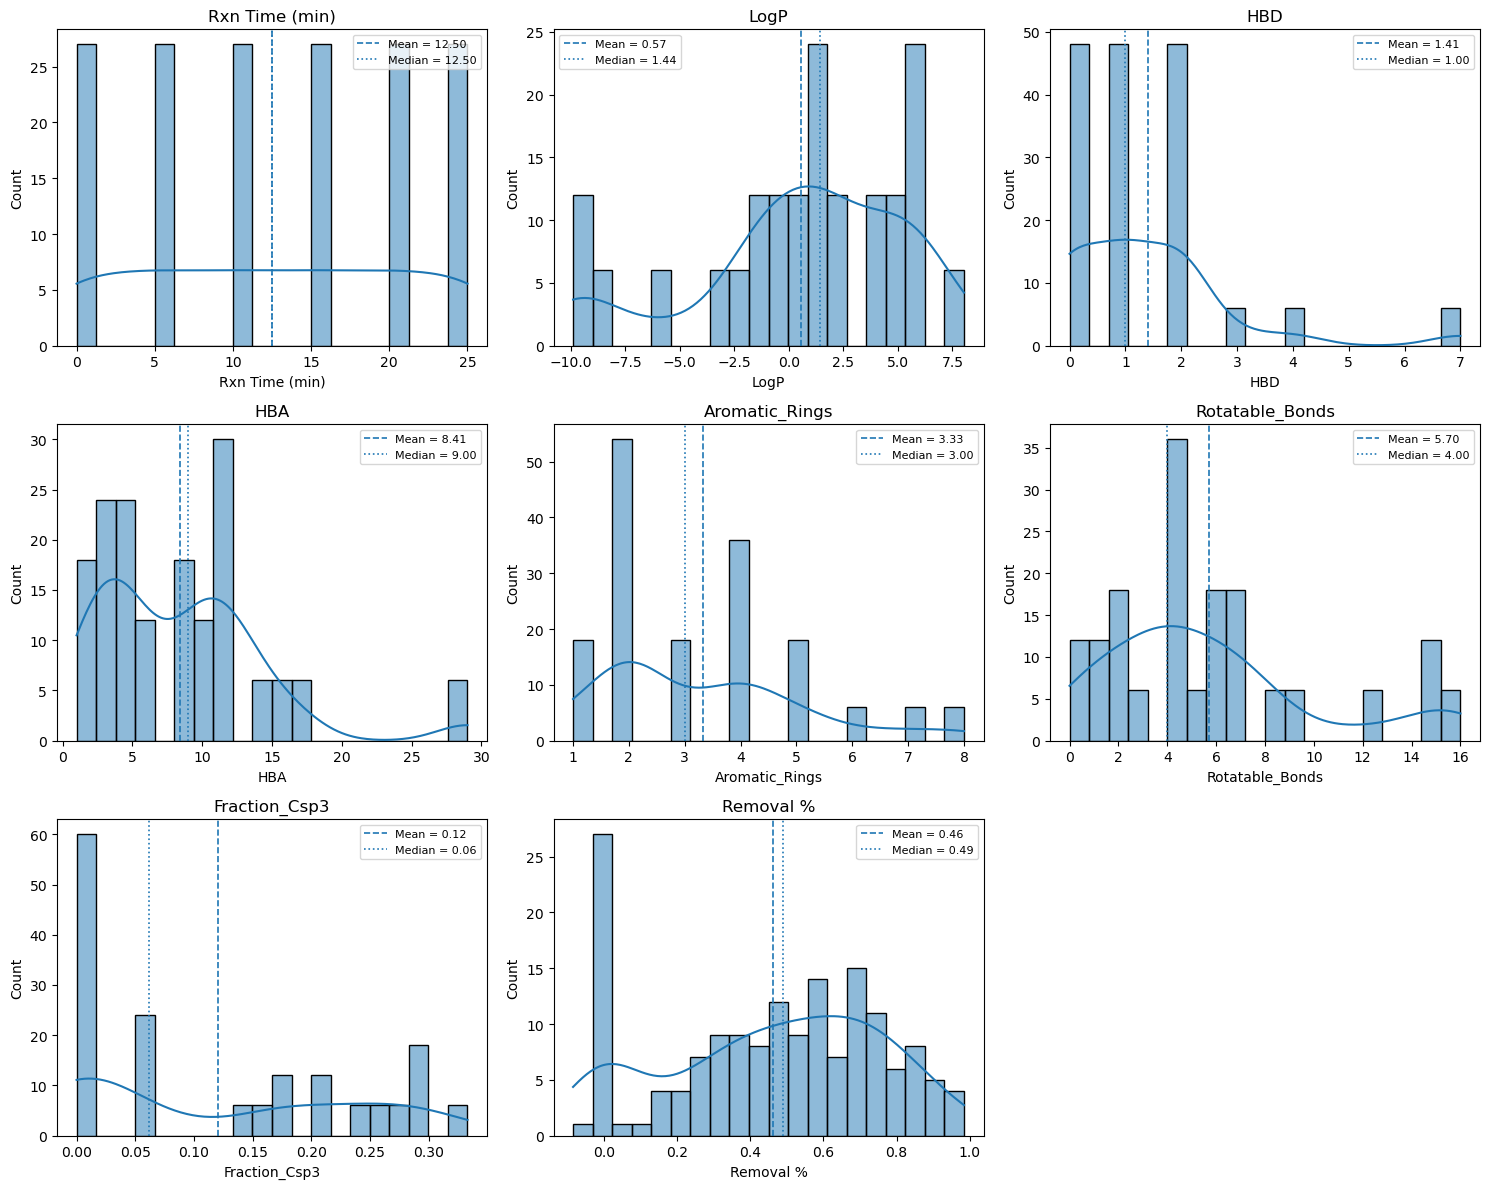

In [17]:
plot_univariate_distributions(
    df,
    NUMERIC_COLS,
    bins=20,
    ncols=3
)

In [18]:
df[TARGET_COL].describe()

count    162.000000
mean       0.461901
std        0.289618
min       -0.083782
25%        0.256301
50%        0.489586
75%        0.693188
max        0.983809
Name: Removal %, dtype: float64

In [19]:
negative_row = df[df[TARGET_COL] < 0]

display(negative_row)

,Dye,Rxn Time (min),Removal %,Full_Name,SMILES,LogP,HBD,HBA,Aromatic_Rings,Rotatable_Bonds,Fraction_Csp3
145,MG,5,-0.083782,Methyl green chloride,CN(C)C1=CC=C(C=C1)C(=C2C=CC(=[N+](C)C)C=C2)C3=...,-1.402,0,1,2,4,0.269


In [20]:
df = df[df[TARGET_COL] >= 0].copy()

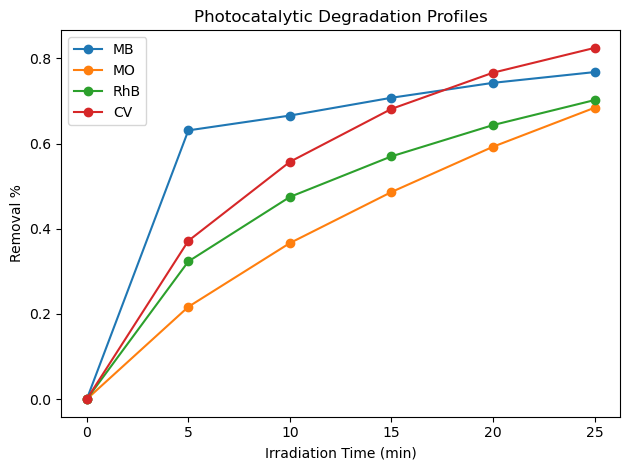

In [21]:
# Plot selected degradation profiles

selected_dyes = [
    "MB",
    "MO",
    "RhB",
    "CV",
]

plt.figure()

for dye in selected_dyes:

    dye_df = (
        df[df["Dye"] == dye]
        .sort_values(TIME_COL)
    )

    plt.plot(
        dye_df[TIME_COL],
        dye_df[TARGET_COL],
        marker="o",
        label=dye
    )

plt.xlabel(
    "Irradiation Time (min)"
)

plt.ylabel(
    TARGET_COL
)

plt.title(
    "Photocatalytic Degradation Profiles"
)

plt.legend()
plt.tight_layout()
plt.show()

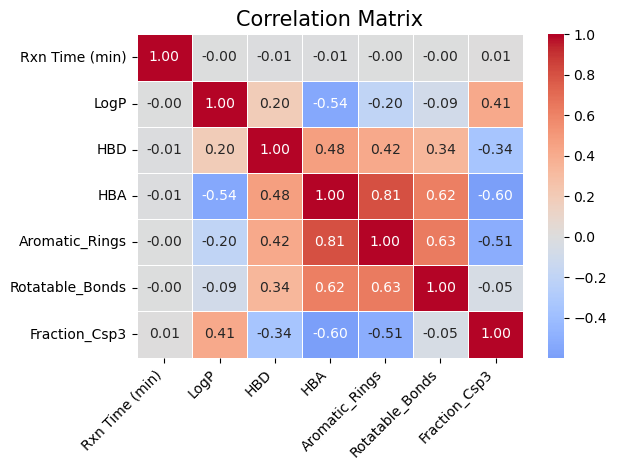

In [22]:
# CORRELATION MATRIX
correlation_cols = (
    [TIME_COL]
    + descriptor_cols
)

corr = df[correlation_cols].corr()
plt.figure()

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
df.to_csv(
    "../data/preprocessed_data.csv",
    index=False
)